#### **1. 핵심 키워드 정리**

- **구획 모델(Compartmental Model)**: 인구 집단을 질병 상태에 따라 감수성자($S$, Susceptible), 감염자($I$, Infective), 회복/제거자($R$, Removed)로 나누고, 시간에 따른 각 구획의 인구 변화를 상미분 방정식으로 나타낸 프레임워크

- **질량 작용 발생률(Mass Action Incidence)**: 감염븨 발생이 감수성자와 감염자의 곱($S \times I$)에 비례한다는 가정

- **기초 감염재생산지수(Basic Reproduction Number, $\mathcal{R}_0$)**: 모든 인구가 감수성자인 상태에서, 단 한 명의 감염자가 회복되기 전까지 직접 감염시키는 평균 2차 감염자의 수를 의미($\mathcal{R}_0 > 1$이면 감염병이 유행, $\mathcal{R}_0 < 1$이면 소멸)

- **최종 규모 관계식(Final Size Relation)**: 유행이 완전히 끝난 후 남게 되는 감수성자의 수($S_{\infty}$)를 초기 상태 및 $\mathcal{R}_0$과 연결해주는 방정식

#### **2. 주요 내용**

1. **Kermack-McKendrick** 모델의 3가지 핵심 가정
    - **균일한 접촉(Mass Action)**: 인구 집단 내 평균적인 개인은 단위 시간당 $\beta N$명과 접촉하여 감염을 전파. 따라서 단위 시간당 새로운 감염은 $\beta S I$만큼 발생
    - **지수적 회복(Exponential Recovery)**: 감염자는 단위 시간당 $\alpha$의 비율로 회복($R$) 구획으로 이동, 이는 감염 기간이 평균 $1/\alpha$인 지수 분포를 따른다는 것을 의미
    - **폐쇄된 인구(Closed Population)과 감염병의 발생 조건**: 감염병이 도는 짧은 기간 동안 출생, 이민, 자연 사망에 의한 인구 변동은 없다고 가정 ($N = S + I + R$)
    
2. **역치 현상(Threshold Behavior)과 감염병의 발생 조건**: 수식을 통해 가장 먼저 묻는 질문은 "질병이 유행할 것인가?""인데, 이는 감염자 수가 $I(t)$가 증가할 것인가($I' = {dI \over dt} > 0$) 감소할 것인가($I' < 0$)로 판단
    - $S > \alpha / \beta$일 때만 $I$가 증가
    - 즉, 초기 감수성자 $S(0)$가 $\alpha/\beta$(임계값)보다 커야만 유행이 발생(**역치 정리(Threshold Theorem)**)

3. **감염병은 왜 모두를 감염시키지 않는가?**
    - $S'(t) = -\beta S I$이므로 $S(t)$는 단조 감소하며, $S(t)$가 계속 줄어들다가 $\alpha/\beta$ 아래로 떨어지면, 그때부터 감염자 $I(t)$도 감소하며 결국 0에 수렴.
    - 질병이 끝났을 때($t \rightarrow \infty$) $S_{\infty} > 0$. 즉, 바이러스가 스스로 퍼질 동력(충분한 감수성자)를 잃어 소멸하는 것이지, 숙주를 모두 감염시켜서 끝나는 것은 아님

4. **Eyam 마을의 흑사병 사례**
    - 이론적인 모델이 실제 데이터에 어떻게 적용되는지 1665년 영국 Eyam 마을의 흑사병 데이터를 통해 확인 
    - 학자들은 초기 감수성자 $S_0$, 초기 감염자 $I_0$, 생존자 $S_{\infty}$ 데이터를 이용해 $\mathcal{R}_0$를 역산하고, 미분방정식을 시뮬레이션하여 실제 사망 패턴이 SIR 모델의 예측과 놀랍도록 일치함을 보임(흑사병은 쥐와 벼룩을 매개로 하는데, 접촉이랑 관계가 있나..?)

#### **3. 챕터 간 연계성**

- **챕터 2.1.1과의 연결**: 역사적으로 관찰된 감염병의 거시적 패턴을 설명하기 위해, 언어로 서술되었던 가설들을 엄밀한 수식으로 옮김

- **이후 챕터들과의 연결**: 본 챕터에서는 가장 단순화된 가정(일정한 총 인구수, 균일한 접촉률 등)을 하나씩 완화해가는 더 복잡한 모델들을 소개(2.1.3 일반화된 접촉률, 2.1.4 잠복기가 있는 SEIR 모델 등)

#### **4. 수식 전개**

1. **SIR 모델의 지배 방정식 (Governing Equation)**

\begin{aligned}
S' = {dS \over dt} &= - \beta S I \\ 
I' = {dI \over dt} &= (\beta S - \alpha) I \\ 
R' = {dR \over dt} &= \alpha I \\ 
\end{aligned}


1.1. **SIR 모델 파이썬 코드**

- 라이브러리 임포트: numpy, scipy.integrate: odeint, matplotlib.pyplot
- 폰트 설정: plt.rcParams['font.family'], plt.rcParams['axes.unicode_minus']
- 모델 정의: y(전시점 상태 [$S_{t-1}$, $I_{t-1}$, $R_{t-1}$]), t(현재 시점), beta(접촉률), alpha(회복률)
    - 전시점 상태 지정
    - dSdt 정의
    - dIdt 정의
    - dRdt 정의
    - Return: [dSdt, dIdt, dRdt]
- 파라미터 및 초기 조건 설징: 파라미터 - beta, alpha / 초기 조건 - N, I0, R0, S0, y0 = [S0, I0, R0]
- 시간 설정: np.linspace
- ODE 풀기: odeint(sir_model, y0, t, args = (beta, alpha))
- 시각화:
    - fig, ax = plt.subplots(figsize = (10, 6))
    - ax.plot(t, S)
    - ax.set_xlabel("시간 (일)")
    - ax.set_title("시간 (일)")
    - ax.legend(fontsize=12)
    - ax.grid(True, alpha=0.3)

기본 재생산수 R₀ = βS₀/α = 2997.00


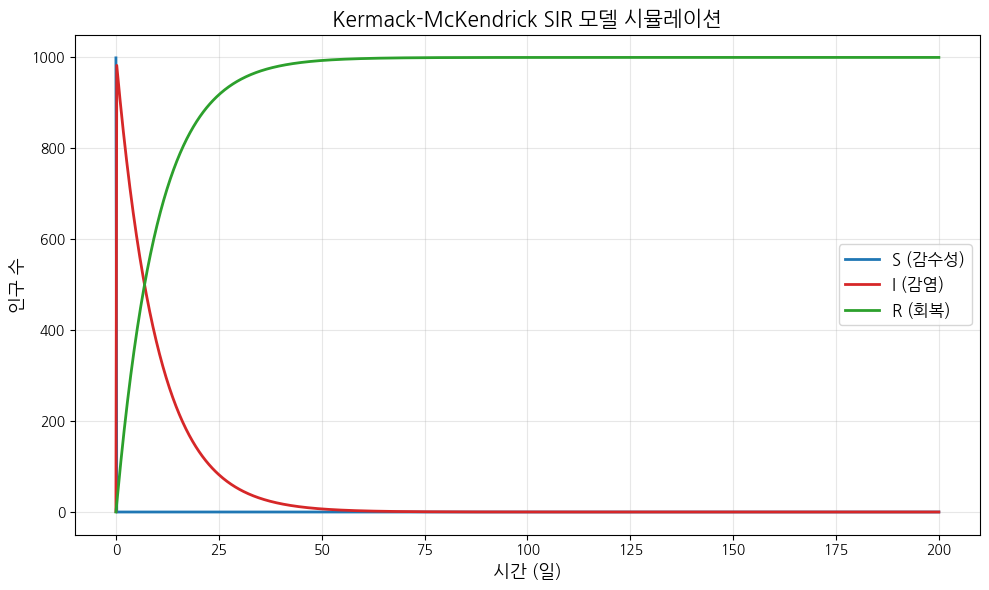

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = "NanumGothic"
plt.rcParams['axes.unicode_minus'] = False

# ── SIR 모델 정의 ──────────────────────────────────
def sir_model(y, t, beta, alpha):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = (beta * S - alpha) * I
    dRdt = alpha * I
    return [dSdt, dIdt, dRdt]

# ── 파라미터 설정 ──────────────────────────────────
beta  = 0.3    # 감염률 (transmission rate)
alpha = 0.1    # 회복률 (recovery rate)

# 초기 조건: S(0), I(0), R(0)
N  = 1000          # 총 인구
I0 = 1             # 초기 감염자
R0 = 0             # 초기 회복자
S0 = N - I0 - R0   # 초기 감수성 인구

y0 = [S0, I0, R0]

# 시간 범위 (일 단위)
t = np.linspace(0, 200, 1000)

# ── ODE 풀기 ───────────────────────────────────────
solution = odeint(sir_model, y0, t, args=(beta, alpha))
S, I, R = solution.T

# ── 기본 재생산수(R₀) 출력 ─────────────────────────
R0_value = beta * S0 / alpha
print(f"기본 재생산수 R₀ = βS₀/α = {R0_value:.2f}")

# ── 시각화 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t, S, label="S (감수성)", color="#1f77b4", linewidth=2)
ax.plot(t, I, label="I (감염)",   color="#d62728", linewidth=2)
ax.plot(t, R, label="R (회복)",   color="#2ca02c", linewidth=2)

ax.set_xlabel("시간 (일)", fontsize=13)
ax.set_ylabel("인구 수",   fontsize=13)
ax.set_title("Kermack-McKendrick SIR 모델 시뮬레이션", fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



1.2. **odeint 직접 구현**

- 주요 내용: 미분방정식의 수치 적분
$$\frac{d\mathbf{y}}{dt} = f(t, \mathbf{y}), \quad \mathbf{y}(t_0) = \mathbf{y}_0$$

- 수치적분 핵심 아이디어: "현재 값 + 작은 시간 간격 × 변화율 = 다음 값"
\begin{aligned}
\frac{dy}{dt} &\approx \frac{y(t + h) - y(t)}{h} \\
y(t + h) &\approx y(t) + h \cdot f(t, y)
\end{aligned}

- 오일러 방법(Euler Method): 가장 단순한 방법
    - 초기값 설정: y = y0, t = t0
    - 시간 간격 h 설정
    - 반복(t < t_end):
        - 기울기 계산: k = f(t, y)
        - 다음 값: y = y + h*k
        - 시간 전진: t = t + h
        - 결과 저장 


2. **기초 감염재생산 지수($\mathcal{R}_0$)**: 초기 인구 $K \approx S(0)$에 감염자가 한 명 들어왔을 때, 이 감염자가 회복되기 전까지(평균 감염 기간 $1/\alpha$) 감염시키는 사람의 수(단위 시간당 감염률은 $\beta K$)

\begin{aligned}
\mathcal{R}_0 = {\beta K \over \alpha}
\end{aligned}



3. **위상 평면 궤적 (Phase Plane Orbit)**: 시간 $t$를 소거하여 $S$와 $I$의 직접적인 관계를 구하기 위해 $I'$를 $S'$로 나눔
\begin{aligned}
{dI \over dS} = {I' \over S'} = {(\beta S - \alpha) I \over - \beta S I} = -1 + {\alpha \over \beta S}
\end{aligned}
이를 $S$에 대해 적분하면 다음의 궤적 방정식을 얻음 (c는 적분 상수)
\begin{aligned}
I = -S + {\alpha \over \beta} log S + c
\end{aligned}



4. **최종 규모 관계식(Final Size Relation)**
감염병이 시작될 때($t=0$) $S(0) = S_0 \approx K$, $I(0) = I_0 \approx 0$이라 하고, 감염병이 종식되었을 때($t \rightarrow infty$) $S(\infty) = S_{\infty}$, $I(\infty) = 0$이라 하자. \
위 궤적 방정식에서 적분 상수 c만 남도록 하는 함수 $V(S, I) = S + I - {\alpha \over \beta} log(S)$로 정의하면, $V$는 궤적 위에서 일정하며, $V(S_0, I_0) = V(S_{\infty}, 0)$가 성립한다.
\begin{aligned}
S_0 + I_0 - {\alpha \over \beta} log S_0 = S_{\infty} + 0 - {\alpha \over \beta} log S_{\infty}
\end{aligned}
$S_0 + I_0 = K$이고 양변을 정리하면:
\begin{aligned}
K = S_{\infty} = {\alpha \over \beta} (log S_0 - log S_{\infty})
\end{aligned}
여기에 ${\beta \over \alpha} = {\mathcal{R}_0 \over K}$을 대입하여 식을 변형하면 다음의 최종 규모 관계식을 얻는다.
\begin{aligned}
log S_0 - log S_{\infty} = \mathcal{R}_0 (1 - {S_{\infty} \over K})
\end{aligned}



5. **감염 초기 성장률 (Initial Growth Rate, $\gamma$)** : 유행 초기에는 $S(t) \approx K$로 근사할 수 있으므로, $I' \approx (\beta K - \alpha) I$가 된다.
\begin{aligned}
I(t) \approx I_0 e^{\gamma t}, \ \ \text{where} \ \ \gamma = \beta K -\alpha = \alpha (\mathcal{R}_0 - 1)
\end{aligned}
초기 감염이 기하급수적으로 증가하는 속도 $\gamma$를 데이터로 측정하면 $\beta$를 역산할 수 있다.
\begin{aligned}
\beta = {\gamma + \alpha \over K}
\end{aligned}



6. **최대 감염자 수(Maximum Infectives, $I_max$)**: 의료 시설의 수용 한계를 평가할 때 중요한 수식으로, $I$가 최대가 되는 시점인 $I'=0$일 때, 즉 $S = \alpha / \beta$이다. 이 $S$값을 궤적 방정식에 대입하면:

\begin{aligned}
I &= - S + {\alpha \over \beta} log S + c \\
I_{max} &= c - {\alpha \over \beta} + {\alpha \over \beta} log {\alpha \over \beta} \\
I_{max} &= S_0 + I_0 - {\alpha \over \beta} log S_0  - {\alpha \over \beta} + {\alpha \over \beta} log {\alpha \over \beta}
\end{aligned}